# LA Mayoral Primary Model

This notebook estimates the probability that Spencer Pratt finishes second in the Los Angeles mayoral primary by simulating the distribution of ballots that have not yet been counted.

The model is scenario-based. It is not a prediction market, an official forecast, or a claim that the stated assumptions are uniquely correct. The central calculation is:

```text
final candidate votes = current candidate votes + simulated share of remaining votes * remaining votes
```

The model uses `raw_vote_data.csv`, where candidates run down the rows and vote-count drops run across the columns. Bass, Pratt, and Raman are modeled directly; all other candidates are bucketed into `Other`.

## Scenario Grid

The notebook runs the model across a grid:

- trailing vote-drop windows: `N = {1, 5, 9, All except first, etc.}`
- trend strengths: `LATE_TREND_STRENGTH = {float values between 0.0 - 1.0, inclusive}`

For each window, the projection starts with the ballot-weighted candidate share of that selected vote-drop set. For the `All except first` case, the first chronological drop is excluded. Trend strength is applied using the ratio of selected-window share to first-drop share, then the resulting candidate shares are normalized back to 100%.

## How to Use `LATE_TREND_STRENGTH`

`LATE_TREND_STRENGTH` takes values between 0.0 and 1.0, inclusive. This variable adds trend strength to the late-vote counts, nudging the remainder of uncounted votes in the direction of the current aggregate late-vote share distribution. Setting this to 0 assumes stationarity of the overall aggregate share; setting this to 1.0 assumes the remaining uncounted ballots are even more tilted than the aggregate late ballots observed so far. It takes the aggregate late-vote share and applies the observed late-vote-vs-baseline ratio one additional time. After the `LATE_TREND_STRENGTH` adjustment is applied to vote shares, the candidate shares are normalized back to 100%.

Concrete example: suppose Pratt was 30% in the first-drop baseline and 20% in the selected trailing vote-drop window, while Raman was 20% in the first-drop baseline and 30% in the selected trailing vote-drop window. Pratt's observed late-vote-vs-baseline ratio is `20% / 30% = 0.67`; Raman's is `30% / 20% = 1.50`.

| `LATE_TREND_STRENGTH` | Pratt raw calculation | Raman raw calculation | Interpretation |
|---:|---:|---:|---|
| 0.0 | `20% * 0.67^0.0 = 20.0%` | `30% * 1.50^0.0 = 30.0%` | Use the selected trailing-window shares directly. |
| 0.5 | `20% * 0.67^0.5 = 16.3%` | `30% * 1.50^0.5 = 36.7%` | Apply half of the observed late-vote-vs-baseline tilt again. |
| 1.0 | `20% * 0.67^1.0 = 13.3%` | `30% * 1.50^1.0 = 45.0%` | Apply the full observed late-vote-vs-baseline ratio one additional time. |

The table shows Pratt and Raman only to keep the math readable. In the notebook, the same calculation is applied to Bass, Pratt, Raman, and Other, and then all four adjusted shares are normalized back to 100%.


In [1]:
import re
from io import StringIO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from IPython.display import display

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 120,
})

TOTAL_VOTES = 870570  # Estimated total votes cast in the LA Mayoral primary.
ELECTION_DATE = "6/2/2026"

N_SIMS = 100_000
RANDOM_SEED = 42
TRAILING_VOTE_DROP_OPTIONS = [1, 2, 3, 5, 9, "all_except_first"]
LATE_TREND_STRENGTH_VALUES = [0.0, 0.5, 1.0]

SINGLE_DROP_CONCENTRATION = 50
MIN_PROJECTION_CONCENTRATION = 25
MAX_PROJECTION_CONCENTRATION = 2_000
DIRICHLET_EPSILON = 1e-6

candidate_colors = {
    "Bass": "#2F6DB3",
    "Pratt": "#C9362C",
    "Raman": "#54A24B",
    "Other": "#8C6D62",
}
candidate_initials = {
    "Bass": "B",
    "Pratt": "P",
    "Raman": "R",
    "Other": "O",
}
label_box = {
    "facecolor": "#f2f2f2",
    "edgecolor": "#cfcfcf",
    "alpha": 0.92,
    "boxstyle": "round,pad=0.18",
}


## Data

The notebook treats `raw_vote_data.csv` as the raw election input. Rows are candidates, columns are vote-count drops, and cells contain vote counts with optional percentage text.

The drop columns are incremental vote batches, not cumulative totals. The notebook parses the counts, buckets all non-Bass/non-Pratt/non-Raman candidates into `Other`, and uses `TOTAL_VOTES` as the total turnout estimate.

In [2]:
RAW_VOTE_FILE = "raw_vote_data.csv"
candidates = ["Bass", "Pratt", "Raman", "Other"]

candidate_bucket_map = {
    "KAREN RUTH BASS": "Bass",
    "SPENCER PRATT": "Pratt",
    "NITHYA RAMAN": "Raman",
}


def normalize_raw_vote_line(line):
    line = line.strip().rstrip(",").strip()
    if line.startswith('"') and line.endswith('"'):
        line = line[1:-1].replace('""', '"')
    return line.strip()


def parse_vote_counts_from_row(row_text, expected_count):
    row_name, _, row_values = row_text.partition(",")
    row_name = row_name.strip().strip('"')
    if row_name.upper() == "TOTAL VOTES":
        count_matches = re.findall(r"\d[\d,]*", row_values)
    else:
        count_matches = re.findall(r"(\d[\d,]*)\s*\(", row_values)
    if len(count_matches) < expected_count:
        raise ValueError(f"Could not parse {expected_count} vote-count drops for {row_name}.")
    counts = [int(value.replace(",", "")) for value in count_matches[:expected_count]]
    return row_name, counts


with open(RAW_VOTE_FILE, encoding="utf-8-sig") as handle:
    raw_lines = [normalize_raw_vote_line(line) for line in handle if normalize_raw_vote_line(line)]

drop_columns = re.findall(r"\d{1,2}/\d{1,2}\s+\d{1,2}:\d{2}", raw_lines[0])
if not drop_columns:
    raise ValueError("No vote-count drop timestamp columns were found in raw_vote_data.csv.")

raw_vote_records = []
for row_text in raw_lines[1:]:
    row_name, counts = parse_vote_counts_from_row(row_text, len(drop_columns))
    raw_vote_records.append({"Candidate": row_name, **dict(zip(drop_columns, counts))})

raw_votes = pd.DataFrame(raw_vote_records)
raw_votes["Candidate"] = raw_votes["Candidate"].astype(str).str.strip()

election_year = pd.to_datetime(ELECTION_DATE).year
drop_dates = pd.to_datetime([f"{column} {election_year}" for column in drop_columns], format="%m/%d %H:%M %Y")

parsed_votes = raw_votes.copy()

total_vote_row = parsed_votes[parsed_votes["Candidate"].str.upper() == "TOTAL VOTES"]
candidate_vote_rows = parsed_votes[parsed_votes["Candidate"].str.upper() != "TOTAL VOTES"].copy()
candidate_vote_rows["Bucket"] = candidate_vote_rows["Candidate"].str.upper().map(candidate_bucket_map).fillna("Other")

bucketed_drop_votes = (
    candidate_vote_rows
    .groupby("Bucket")[drop_columns]
    .sum()
    .reindex(candidates, fill_value=0)
)

drop_votes = bucketed_drop_votes.T.copy()
drop_votes.index = drop_dates
drop_votes.index.name = "Drop Date"
drop_votes = drop_votes.sort_index()
drop_votes["Total Drop Votes"] = drop_votes[candidates].sum(axis=1)

drop_vote_shares = drop_votes[candidates].div(drop_votes["Total Drop Votes"], axis=0)

if not total_vote_row.empty:
    raw_total_drop_votes = pd.Series(total_vote_row.iloc[0][drop_columns].to_numpy(dtype=float), index=drop_dates).sort_index()
    mismatched_total_drops = raw_total_drop_votes[raw_total_drop_votes != drop_votes["Total Drop Votes"]]
    if len(mismatched_total_drops) > 0:
        raise ValueError("The Total votes row does not match the sum of parsed candidate vote rows.")

print(f"Loaded {len(drop_votes):,} vote-count drop(s) from {RAW_VOTE_FILE}.")
print(f"Parsed {len(candidate_vote_rows):,} candidate row(s); non-major candidates are bucketed as Other.")


Loaded 17 vote-count drop(s) from raw_vote_data.csv.
Parsed 14 candidate row(s); non-major candidates are bucketed as Other.


## Current Vote Count and Scenario Windows

The current vote count is the sum of all parsed drops. Remaining votes are calculated from `TOTAL_VOTES`.

The first chronological drop is used as the baseline reference for trend multipliers and shift arrows. Each scenario window then selects either the latest N drops or all drops after the first one.

In [3]:
assert TOTAL_VOTES > 0, "TOTAL_VOTES must be positive"
assert N_SIMS > 0, "N_SIMS must be positive"
assert all(0 <= value <= 1 for value in LATE_TREND_STRENGTH_VALUES), "Trend strengths should be between 0.0 and 1.0"
assert SINGLE_DROP_CONCENTRATION > 0, "SINGLE_DROP_CONCENTRATION must be positive"
assert MIN_PROJECTION_CONCENTRATION > 0, "MIN_PROJECTION_CONCENTRATION must be positive"
assert MAX_PROJECTION_CONCENTRATION >= MIN_PROJECTION_CONCENTRATION, "MAX_PROJECTION_CONCENTRATION must be >= MIN_PROJECTION_CONCENTRATION"
assert DIRICHLET_EPSILON > 0, "DIRICHLET_EPSILON must be positive"

valid_drop_votes = drop_votes.loc[drop_votes["Total Drop Votes"] > 0].copy()
valid_drop_shares = drop_vote_shares.loc[valid_drop_votes.index].copy()

if len(valid_drop_votes) < 2:
    raise ValueError("raw_vote_data.csv needs at least two positive vote-count drops for this scenario-grid model.")

first_drop_timestamp = valid_drop_votes.index.min()
first_drop_votes = valid_drop_votes.loc[first_drop_timestamp]
first_drop_share = valid_drop_shares.loc[first_drop_timestamp]
first_drop_total_votes = float(first_drop_votes["Total Drop Votes"])

current_votes = valid_drop_votes[candidates].sum(axis=0)
current_vote_values = current_votes.reindex(candidates).to_numpy(dtype=float)
total_counted = float(current_votes.sum())
estimated_total_votes = float(TOTAL_VOTES)
remaining_votes = max(estimated_total_votes - total_counted, 0)
counted_pct = total_counted / estimated_total_votes
current_share = current_votes / total_counted


def build_drop_window(option):
    if option == "all_except_first":
        selected_votes = valid_drop_votes.iloc[1:].copy()
        if len(selected_votes) == 0:
            raise ValueError("The all-except-first window has no drops available.")
        requested_label = "All except first"
        sort_order = 10_000
    else:
        requested_n = int(option)
        if requested_n < 1:
            raise ValueError("Trailing vote-drop windows must be positive.")
        used_n = min(requested_n, len(valid_drop_votes))
        selected_votes = valid_drop_votes.tail(used_n).copy()
        requested_label = f"N={requested_n}"
        sort_order = requested_n

    selected_shares = valid_drop_shares.loc[selected_votes.index].copy()
    selected_totals = selected_votes["Total Drop Votes"].copy()
    weighted_share = selected_votes[candidates].sum(axis=0) / selected_totals.sum()

    return {
        "option": option,
        "label": requested_label,
        "sort_order": sort_order,
        "drop_count": len(selected_votes),
        "votes": selected_votes,
        "shares": selected_shares,
        "totals": selected_totals,
        "weighted_share": weighted_share,
        "total_votes": float(selected_totals.sum()),
    }


drop_windows = [build_drop_window(option) for option in TRAILING_VOTE_DROP_OPTIONS]
scenario_row_labels = [window["label"] for window in drop_windows]
trend_column_labels = [f"{value:.1f}" for value in LATE_TREND_STRENGTH_VALUES]

summary_table = pd.DataFrame({
    "Metric": [
        "Election date",
        "Vote-count drops loaded",
        "Estimated total votes",
        "Current counted votes",
        "Counted percentage",
        "Estimated remaining votes",
        "First drop timestamp",
        "First drop votes",
        "Scenario N values",
        "Trend strength values",
    ],
    "Value": [
        pd.to_datetime(ELECTION_DATE).strftime("%Y-%m-%d"),
        f"{len(valid_drop_votes):,}",
        f"{estimated_total_votes:,.0f}",
        f"{total_counted:,.0f}",
        f"{counted_pct:.1%}",
        f"{remaining_votes:,.0f}",
        first_drop_timestamp.strftime("%Y-%m-%d %H:%M"),
        f"{first_drop_total_votes:,.0f}",
        ", ".join(scenario_row_labels),
        ", ".join(trend_column_labels),
    ],
})

current_vote_table = pd.DataFrame({
    "Candidate": candidates,
    "Current Votes": current_votes.reindex(candidates).values,
    "Current Share": current_share.reindex(candidates).values,
    "First Drop Share": first_drop_share.reindex(candidates).values,
})

display(summary_table)
display(
    current_vote_table.style.format({
        "Current Votes": "{:,.0f}",
        "Current Share": "{:.1%}",
        "First Drop Share": "{:.1%}",
    })
)


,Metric,Value
0,Election date,2026-06-02
1,Vote-count drops loaded,17
2,Estimated total votes,"870,570"
3,Current counted votes,"723,472"
4,Counted percentage,83.1%
5,Estimated remaining votes,"147,098"
6,First drop timestamp,2026-06-02 20:17
7,First drop votes,"308,878"
8,Scenario N values,"N=1, N=2, N=3, N=5, N=9, All except first"
9,Trend strength values,"0.0, 0.5, 1.0"


,Candidate,Current Votes,Current Share,First Drop Share
0,Bass,"250,871",34.7%,38.1%
1,Pratt,"193,085",26.7%,27.9%
2,Raman,"196,198",27.1%,20.1%
3,Other,"83,318",11.5%,13.9%


## Drop Composition

The first chart shows the observed composition of every vote-count drop. Each bar is normalized to 100% height and labeled with the number of ballots in that release.

The second chart shows one weighted-composition bar for each scenario window N. These bars do not vary by trend strength; they only show the selected drop-window composition before trend extrapolation.

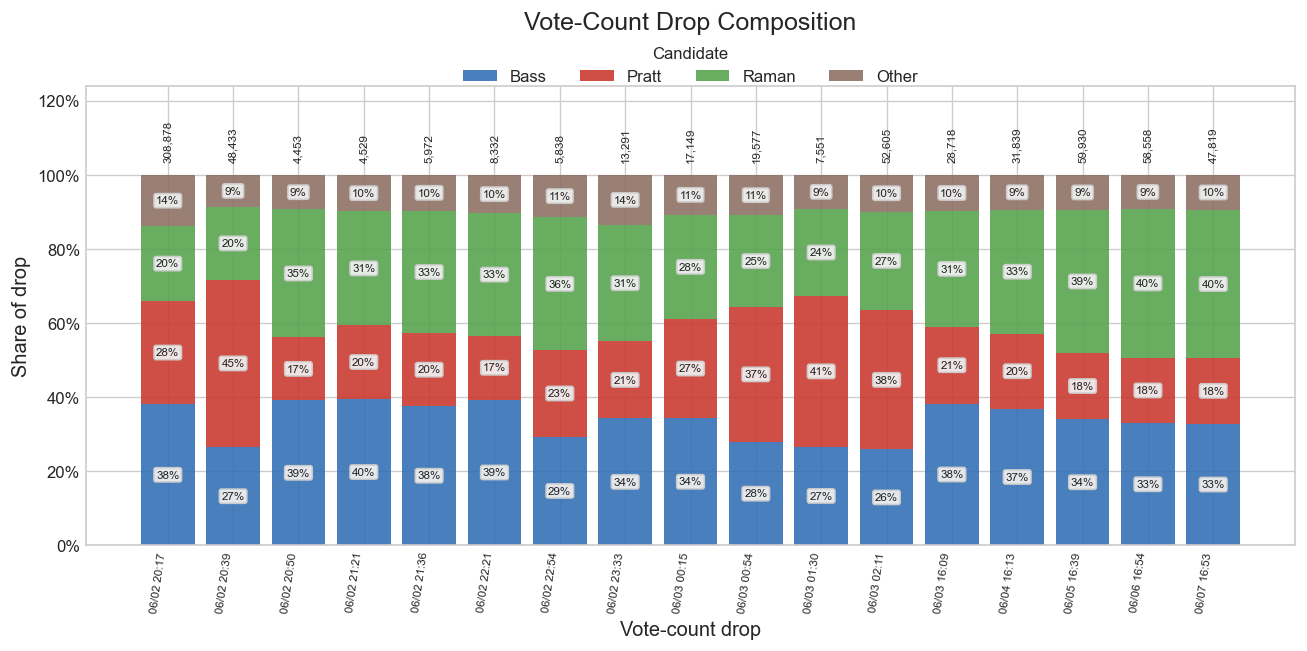

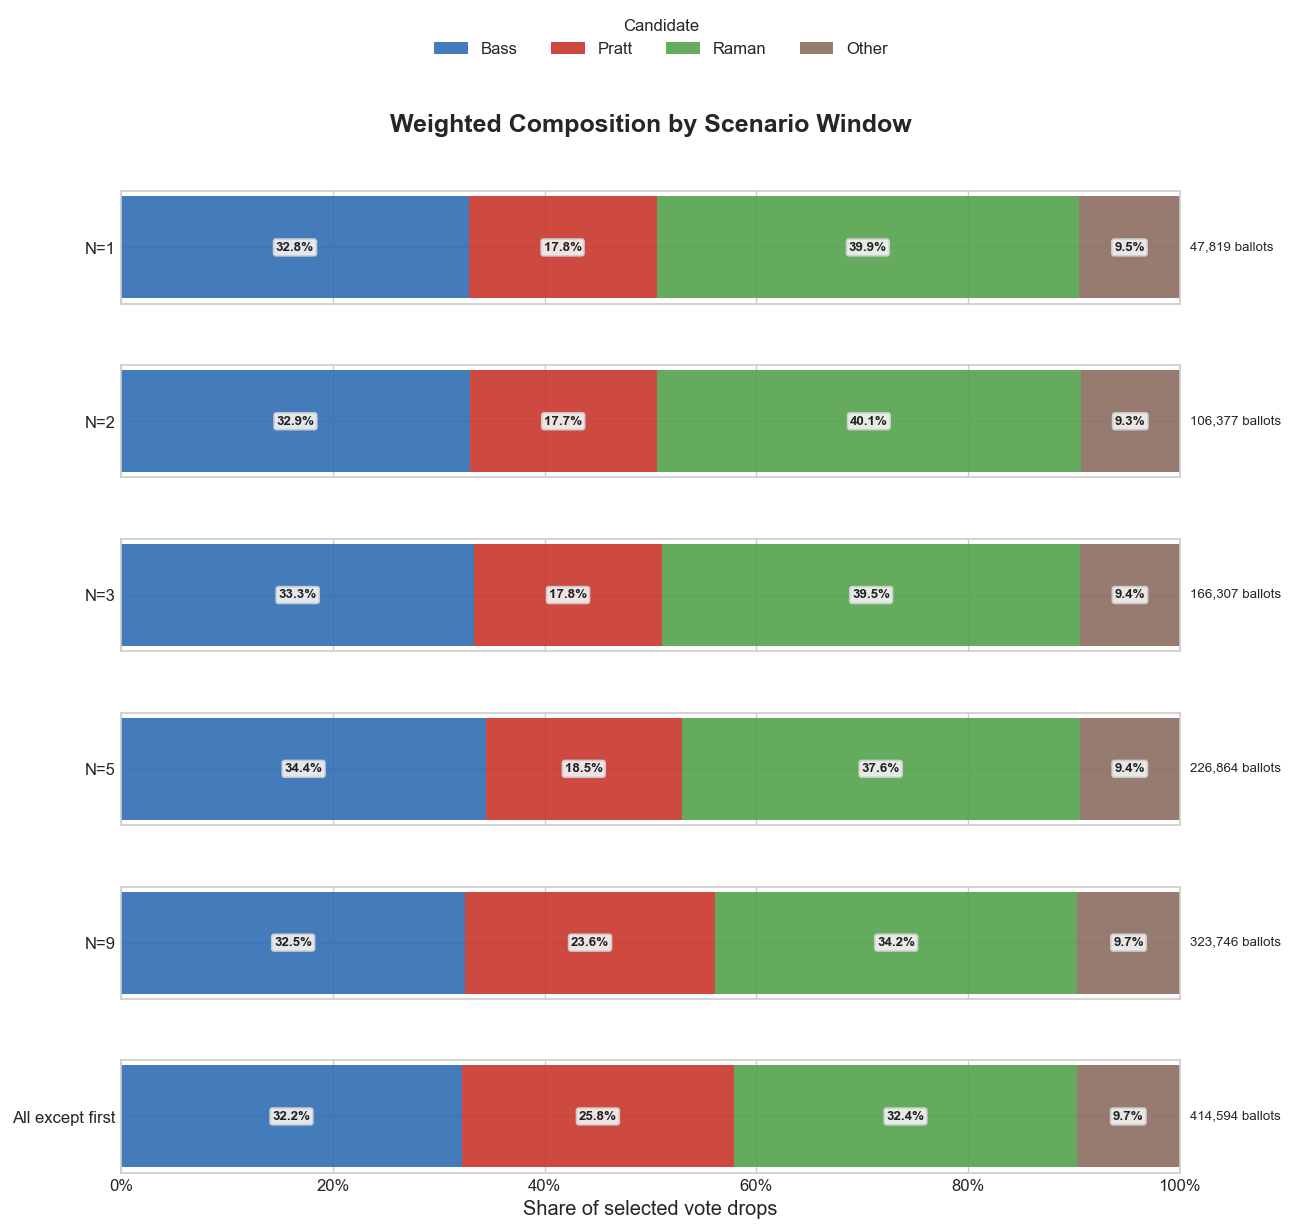

In [4]:
x = np.arange(len(valid_drop_shares))
fig, ax = plt.subplots(figsize=(13, 6.6))
bottom = np.zeros(len(valid_drop_shares))

for candidate in candidates:
    values = valid_drop_shares[candidate].to_numpy(dtype=float)
    ax.bar(
        x,
        values,
        bottom=bottom,
        color=candidate_colors[candidate],
        label=candidate,
        width=0.82,
        alpha=0.88,
    )
    for idx, share in enumerate(values):
        if share >= 0.045:
            ax.text(
                idx,
                bottom[idx] + share / 2,
                f"{share:.0%}",
                ha="center",
                va="center",
                fontsize=7,
                color="#222222",
                bbox=label_box,
            )
    bottom += values

for idx, total_votes_in_drop in enumerate(valid_drop_votes["Total Drop Votes"]):
    ax.text(
        idx,
        1.035,
        f"{total_votes_in_drop:,.0f}",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90,
    )

ax.set_title("Vote-Count Drop Composition", pad=34)
ax.set_ylabel("Share of drop")
ax.set_xlabel("Vote-count drop")
ax.set_ylim(0, 1.24)
ax.set_xticks(x)
ax.set_xticklabels(
    [date.strftime("%m/%d %H:%M") for date in valid_drop_shares.index],
    rotation=82,
    ha="right",
    fontsize=7,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(
    title="Candidate",
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=4,
    frameon=False,
)
fig.subplots_adjust(top=0.82, bottom=0.24)
plt.show()

fig, axes = plt.subplots(
    nrows=len(drop_windows),
    ncols=1,
    figsize=(12, 1.65 * len(drop_windows) + 1.3),
    sharex=True,
)
if len(drop_windows) == 1:
    axes = [axes]

for ax, window in zip(axes, drop_windows):
    left = 0.0
    for candidate in candidates:
        share = float(window["weighted_share"][candidate])
        ax.barh(
            [window["label"]],
            [share],
            left=left,
            color=candidate_colors[candidate],
            label=candidate,
            alpha=0.9,
        )
        if share >= 0.045:
            ax.text(
                left + share / 2,
                0,
                f"{share:.1%}",
                ha="center",
                va="center",
                color="#222222",
                fontweight="bold",
                fontsize=8,
                bbox=label_box,
            )
        left += share
    ax.text(
        1.01,
        0,
        f"{window['total_votes']:,.0f} ballots",
        ha="left",
        va="center",
        fontsize=8,
        transform=ax.get_yaxis_transform(),
    )
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

axes[0].set_title("Weighted Composition by Scenario Window", pad=36, fontweight="bold")
axes[-1].set_xlabel("Share of selected vote drops")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles[:len(candidates)],
    labels[:len(candidates)],
    title="Candidate",
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=4,
    frameon=False,
)
fig.subplots_adjust(top=0.84, right=0.86, hspace=0.55)
plt.show()


## Scenario Simulation

Each scenario is a combination of one vote-drop window and one trend strength. Within a scenario:

```text
window share = ballot-weighted share of selected drops
trend multiplier = (window share / first drop share) ** trend strength
projection center = normalize(window share * trend multiplier)
```

The remaining-vote shares are then simulated from a Dirichlet distribution centered on that projection center.

In [5]:
def dirichlet_alpha_from_mean(mean_vec, concentration):
    safe_mean = np.clip(np.asarray(mean_vec, dtype=float), DIRICHLET_EPSILON, None)
    safe_mean = safe_mean / safe_mean.sum()
    return safe_mean * concentration


def estimate_dirichlet_concentration(mean_share, batch_shares, batch_weights, variance_center_share=None):
    if len(batch_shares) < 2:
        return SINGLE_DROP_CONCENTRATION, "Fallback: fewer than 2 selected drops"

    weights = pd.Series(batch_weights, index=batch_shares.index, dtype=float)
    weights = weights / weights.sum()
    center = mean_share if variance_center_share is None else variance_center_share
    centered_batch_shares = batch_shares.subtract(center, axis=1)
    batch_variance = centered_batch_shares.pow(2).mul(weights, axis=0).sum(axis=0)

    effective_batch_count = 1 / np.square(weights).sum()
    if effective_batch_count > 1:
        batch_variance = batch_variance * (effective_batch_count / (effective_batch_count - 1))

    estimates = []
    for candidate in candidates:
        mu = float(mean_share[candidate])
        var = float(batch_variance[candidate])
        if DIRICHLET_EPSILON < mu < 1 - DIRICHLET_EPSILON and var > 0:
            estimate = (mu * (1 - mu) / var) - 1
            if np.isfinite(estimate) and estimate > 0:
                estimates.append(estimate)

    if not estimates:
        return MAX_PROJECTION_CONCENTRATION, "Fallback: no measurable selected-drop variance"

    raw_estimate = float(np.median(estimates))
    clipped_estimate = float(np.clip(raw_estimate, MIN_PROJECTION_CONCENTRATION, MAX_PROJECTION_CONCENTRATION))
    return clipped_estimate, "Estimated from ballot-weighted variance of selected drops"


def run_scenario(window, trend_strength, scenario_index):
    window_share = window["weighted_share"].copy()
    trend_base = window_share / first_drop_share.replace(0, np.nan)
    trend_base = trend_base.replace([np.inf, -np.inf], np.nan)
    trend_multiplier = trend_base.fillna(1.0) ** trend_strength
    center_weights = window_share * trend_multiplier
    projection_center = center_weights / center_weights.sum()
    projection_center_vec = projection_center.reindex(candidates).to_numpy(dtype=float)

    concentration, concentration_source = estimate_dirichlet_concentration(
        projection_center,
        window["shares"],
        window["totals"],
        variance_center_share=window_share,
    )

    rng = np.random.default_rng(RANDOM_SEED + scenario_index)
    alpha = dirichlet_alpha_from_mean(projection_center_vec, concentration)
    simulated_remaining_shares = rng.dirichlet(alpha, size=N_SIMS)
    sim_shares = pd.DataFrame(simulated_remaining_shares, columns=candidates)

    simulated_remaining_votes = simulated_remaining_shares * remaining_votes
    simulated_final_votes = current_vote_values + simulated_remaining_votes
    final_votes = pd.DataFrame(simulated_final_votes, columns=candidates)

    ranks = final_votes.rank(axis=1, ascending=False, method="min")
    pratt_second = ranks["Pratt"] == 2
    raman_second = ranks["Raman"] == 2
    bass_first = ranks["Bass"] == 1
    pratt_beats_raman = final_votes["Pratt"] > final_votes["Raman"]
    pratt_raman_margin = final_votes["Pratt"] - final_votes["Raman"]

    simulated_mean_remaining_share = sim_shares.mean()
    simulated_median_final_votes = final_votes.median()
    simulated_median_final_share = final_votes.div(final_votes.sum(axis=1), axis=0).median()

    summary = {
        "N Window": window["label"],
        "Trend Strength": trend_strength,
        "Selected Drop Count": window["drop_count"],
        "Selected Ballots": window["total_votes"],
        "Projection Concentration": concentration,
        "P(Pratt Finishes Second)": pratt_second.mean(),
        "P(Raman Finishes Second)": raman_second.mean(),
        "P(Bass Finishes First)": bass_first.mean(),
        "P(Pratt Beats Raman)": pratt_beats_raman.mean(),
        "Median Pratt-Raman Margin": pratt_raman_margin.median(),
        "5th Percentile Margin": pratt_raman_margin.quantile(0.05),
        "95th Percentile Margin": pratt_raman_margin.quantile(0.95),
    }

    candidate_rows = []
    for candidate in candidates:
        candidate_rows.append({
            "N Window": window["label"],
            "Trend Strength": trend_strength,
            "Candidate": candidate,
            "Current Votes": current_votes[candidate],
            "Current Share": current_share[candidate],
            "First Drop Share": first_drop_share[candidate],
            "Window Share": window_share[candidate],
            "Trend Multiplier": trend_multiplier[candidate],
            "Projection Center Share": projection_center[candidate],
            "Simulated Mean Remaining Share": simulated_mean_remaining_share[candidate],
            "Simulated Median Final Votes": simulated_median_final_votes[candidate],
            "Simulated Median Final Share": simulated_median_final_share[candidate],
        })

    return {
        "window": window,
        "trend_strength": trend_strength,
        "key": (window["label"], trend_strength),
        "projection_center": projection_center,
        "trend_multiplier": trend_multiplier,
        "concentration": concentration,
        "concentration_source": concentration_source,
        "sim_shares": sim_shares,
        "simulated_mean_remaining_share": simulated_mean_remaining_share,
        "summary": summary,
        "candidate_rows": candidate_rows,
    }


scenario_results = []
scenario_lookup = {}
scenario_index = 0
for window in drop_windows:
    for trend_strength in LATE_TREND_STRENGTH_VALUES:
        result = run_scenario(window, trend_strength, scenario_index)
        scenario_results.append(result)
        scenario_lookup[result["key"]] = result
        scenario_index += 1

scenario_summary_table = pd.DataFrame([result["summary"] for result in scenario_results])
scenario_candidate_table = pd.DataFrame([row for result in scenario_results for row in result["candidate_rows"]])

print(f"Ran {len(scenario_results):,} scenarios: {len(drop_windows):,} N windows x {len(LATE_TREND_STRENGTH_VALUES):,} trend strengths.")
display(
    scenario_summary_table.style.format({
        "Trend Strength": "{:.1f}",
        "Selected Ballots": "{:,.0f}",
        "Projection Concentration": "{:,.0f}",
        "P(Pratt Finishes Second)": "{:.1%}",
        "P(Raman Finishes Second)": "{:.1%}",
        "P(Bass Finishes First)": "{:.1%}",
        "P(Pratt Beats Raman)": "{:.1%}",
        "Median Pratt-Raman Margin": "{:,.0f}",
        "5th Percentile Margin": "{:,.0f}",
        "95th Percentile Margin": "{:,.0f}",
    })
)


Ran 18 scenarios: 6 N windows x 3 trend strengths.


,N Window,Trend Strength,Selected Drop Count,Selected Ballots,Projection Concentration,P(Pratt Finishes Second),P(Raman Finishes Second),P(Bass Finishes First),P(Pratt Beats Raman),Median Pratt-Raman Margin,5th Percentile Margin,95th Percentile Margin
0,N=1,0.0,1,"47,819",50,1.0%,98.5%,99.5%,1.0%,"-36,076","-59,892","-10,694"
1,N=1,0.5,1,"47,819",50,0.0%,86.6%,86.7%,0.0%,"-60,580","-83,271","-35,381"
2,N=1,1.0,1,"47,819",50,0.0%,36.4%,36.4%,0.0%,"-83,721","-103,956","-59,767"
3,N=2,0.0,2,"106,377","2,000",0.0%,100.0%,100.0%,0.0%,"-36,014","-39,930","-32,064"
4,N=2,0.5,2,"106,377","2,000",0.0%,100.0%,100.0%,0.0%,"-60,534","-64,308","-56,692"
5,N=2,1.0,2,"106,377","2,000",0.0%,2.2%,2.2%,0.0%,"-83,497","-86,992","-79,917"
6,N=3,0.0,3,"166,307","2,000",0.0%,100.0%,100.0%,0.0%,"-35,130","-39,031","-31,166"
7,N=3,0.5,3,"166,307","2,000",0.0%,100.0%,100.0%,0.0%,"-59,117","-62,932","-55,293"
8,N=3,1.0,3,"166,307","2,000",0.0%,15.7%,15.7%,0.0%,"-81,685","-85,193","-78,111"
9,N=5,0.0,5,"226,864",632,0.0%,100.0%,100.0%,0.0%,"-31,247","-38,226","-24,235"


## Simulated Composition of Remaining Ballots

Rows are vote-drop windows. Columns are trend strengths. Dotted lines show first-drop shares; dashed lines show each scenario's projection center. Arrows show how the projection center shifts from the first-drop baseline.

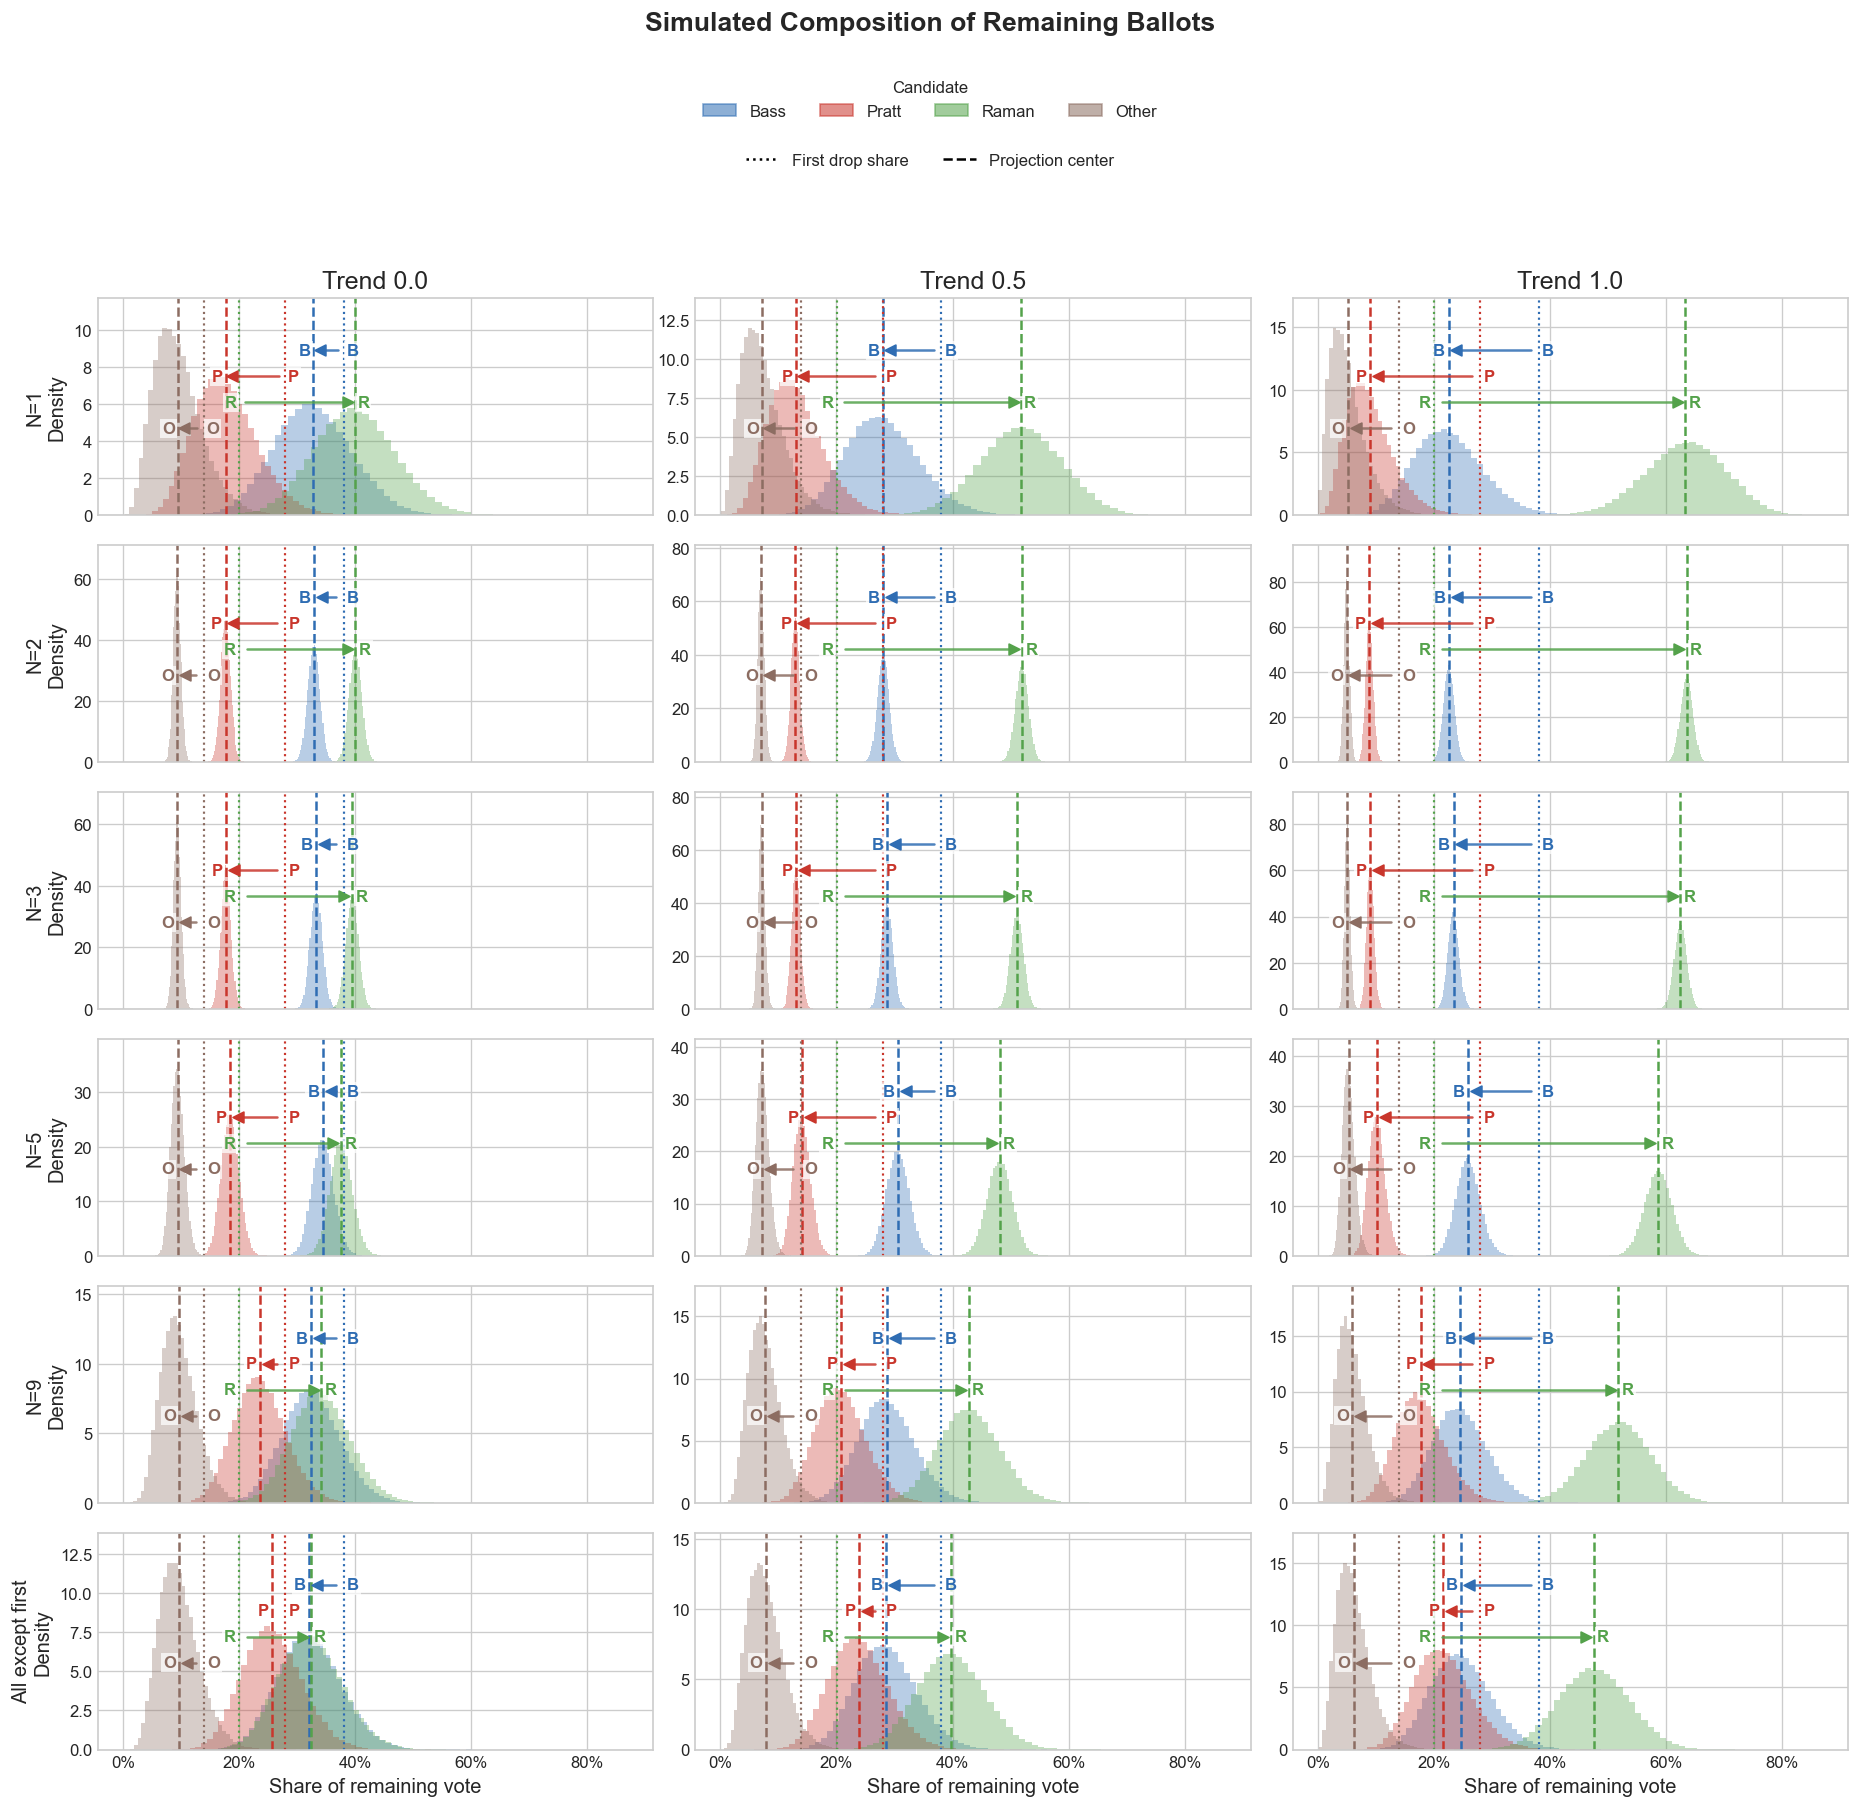

In [6]:
n_rows = len(drop_windows)
n_cols = len(LATE_TREND_STRENGTH_VALUES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 2.35 * n_rows + 1.0), sharex=True, sharey=False)
if n_rows == 1:
    axes = np.array([axes])
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)

candidate_label_y = {
    "Bass": 0.76,
    "Pratt": 0.64,
    "Raman": 0.52,
    "Other": 0.40,
}

for row_idx, window in enumerate(drop_windows):
    for col_idx, trend_strength in enumerate(LATE_TREND_STRENGTH_VALUES):
        ax = axes[row_idx, col_idx]
        result = scenario_lookup[(window["label"], trend_strength)]
        sim_shares = result["sim_shares"]
        projection_center = result["projection_center"]

        panel_density_max = 0
        for candidate in candidates:
            heights, _, _ = ax.hist(
                sim_shares[candidate],
                bins=45,
                alpha=0.34,
                density=True,
                color=candidate_colors[candidate],
                label=candidate,
            )
            panel_density_max = max(panel_density_max, float(np.max(heights)))
            ax.axvline(first_drop_share[candidate], color=candidate_colors[candidate], linestyle=":", linewidth=1.3)
            ax.axvline(projection_center[candidate], color=candidate_colors[candidate], linestyle="--", linewidth=1.5)

        ax.set_ylim(0, panel_density_max * 1.16)
        for candidate in candidates:
            baseline_x = first_drop_share[candidate]
            projected_x = projection_center[candidate]
            label_y = ax.get_ylim()[1] * candidate_label_y[candidate]
            x_span = ax.get_xlim()[1] - ax.get_xlim()[0]
            label_gap = 0.006 * x_span
            arrow_padding = 0.014 * x_span
            direction = np.sign(projected_x - baseline_x)
            if direction != 0:
                baseline_label_x = baseline_x - direction * label_gap
                projected_label_x = projected_x + direction * label_gap
                baseline_label_ha = "right" if direction > 0 else "left"
                projected_label_ha = "left" if direction > 0 else "right"
                arrow_start = baseline_x + direction * arrow_padding
                arrow_end = projected_x - direction * arrow_padding
                if direction * (arrow_end - arrow_start) > 0:
                    ax.plot(
                        [arrow_start, arrow_end],
                        [label_y, label_y],
                        color=candidate_colors[candidate],
                        linewidth=1.5,
                        alpha=0.85,
                        solid_capstyle="round",
                        zorder=8,
                    )
                    ax.scatter(
                        [arrow_end],
                        [label_y],
                        marker=">" if direction > 0 else "<",
                        s=42,
                        color=candidate_colors[candidate],
                        zorder=8,
                    )
            else:
                baseline_label_x = baseline_x - label_gap
                projected_label_x = projected_x + label_gap
                baseline_label_ha = "right"
                projected_label_ha = "left"
            for x_value, ha in [(baseline_label_x, baseline_label_ha), (projected_label_x, projected_label_ha)]:
                ax.text(
                    x_value,
                    label_y,
                    candidate_initials[candidate],
                    color=candidate_colors[candidate],
                    fontweight="bold",
                    ha=ha,
                    va="center",
                    zorder=9,
                    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.72, "pad": 1.2},
                )

        if row_idx == 0:
            ax.set_title(f"Trend {trend_strength:.1f}")
        if col_idx == 0:
            ax.set_ylabel(f"{window['label']}\nDensity")
        if row_idx == n_rows - 1:
            ax.set_xlabel("Share of remaining vote")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))

candidate_handles = [plt.Rectangle((0, 0), 1, 1, color=candidate_colors[candidate], alpha=0.55) for candidate in candidates]
line_handles = [
    plt.Line2D([0], [0], color="black", linestyle=":", label="First drop share"),
    plt.Line2D([0], [0], color="black", linestyle="--", label="Projection center"),
]
fig.legend(candidate_handles, candidates, title="Candidate", loc="upper center", bbox_to_anchor=(0.5, 0.965), ncol=4, frameon=False)
fig.legend(handles=line_handles, loc="upper center", bbox_to_anchor=(0.5, 0.925), ncol=2, frameon=False)
fig.suptitle("Simulated Composition of Remaining Ballots", y=0.995, fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.885])
plt.show()


## Win Map

Rows are vote-drop windows. Columns are trend strengths. Each panel varies Pratt and Raman shares of the remaining vote while holding `Other` fixed at that scenario's simulated mean. Bass receives the residual share.

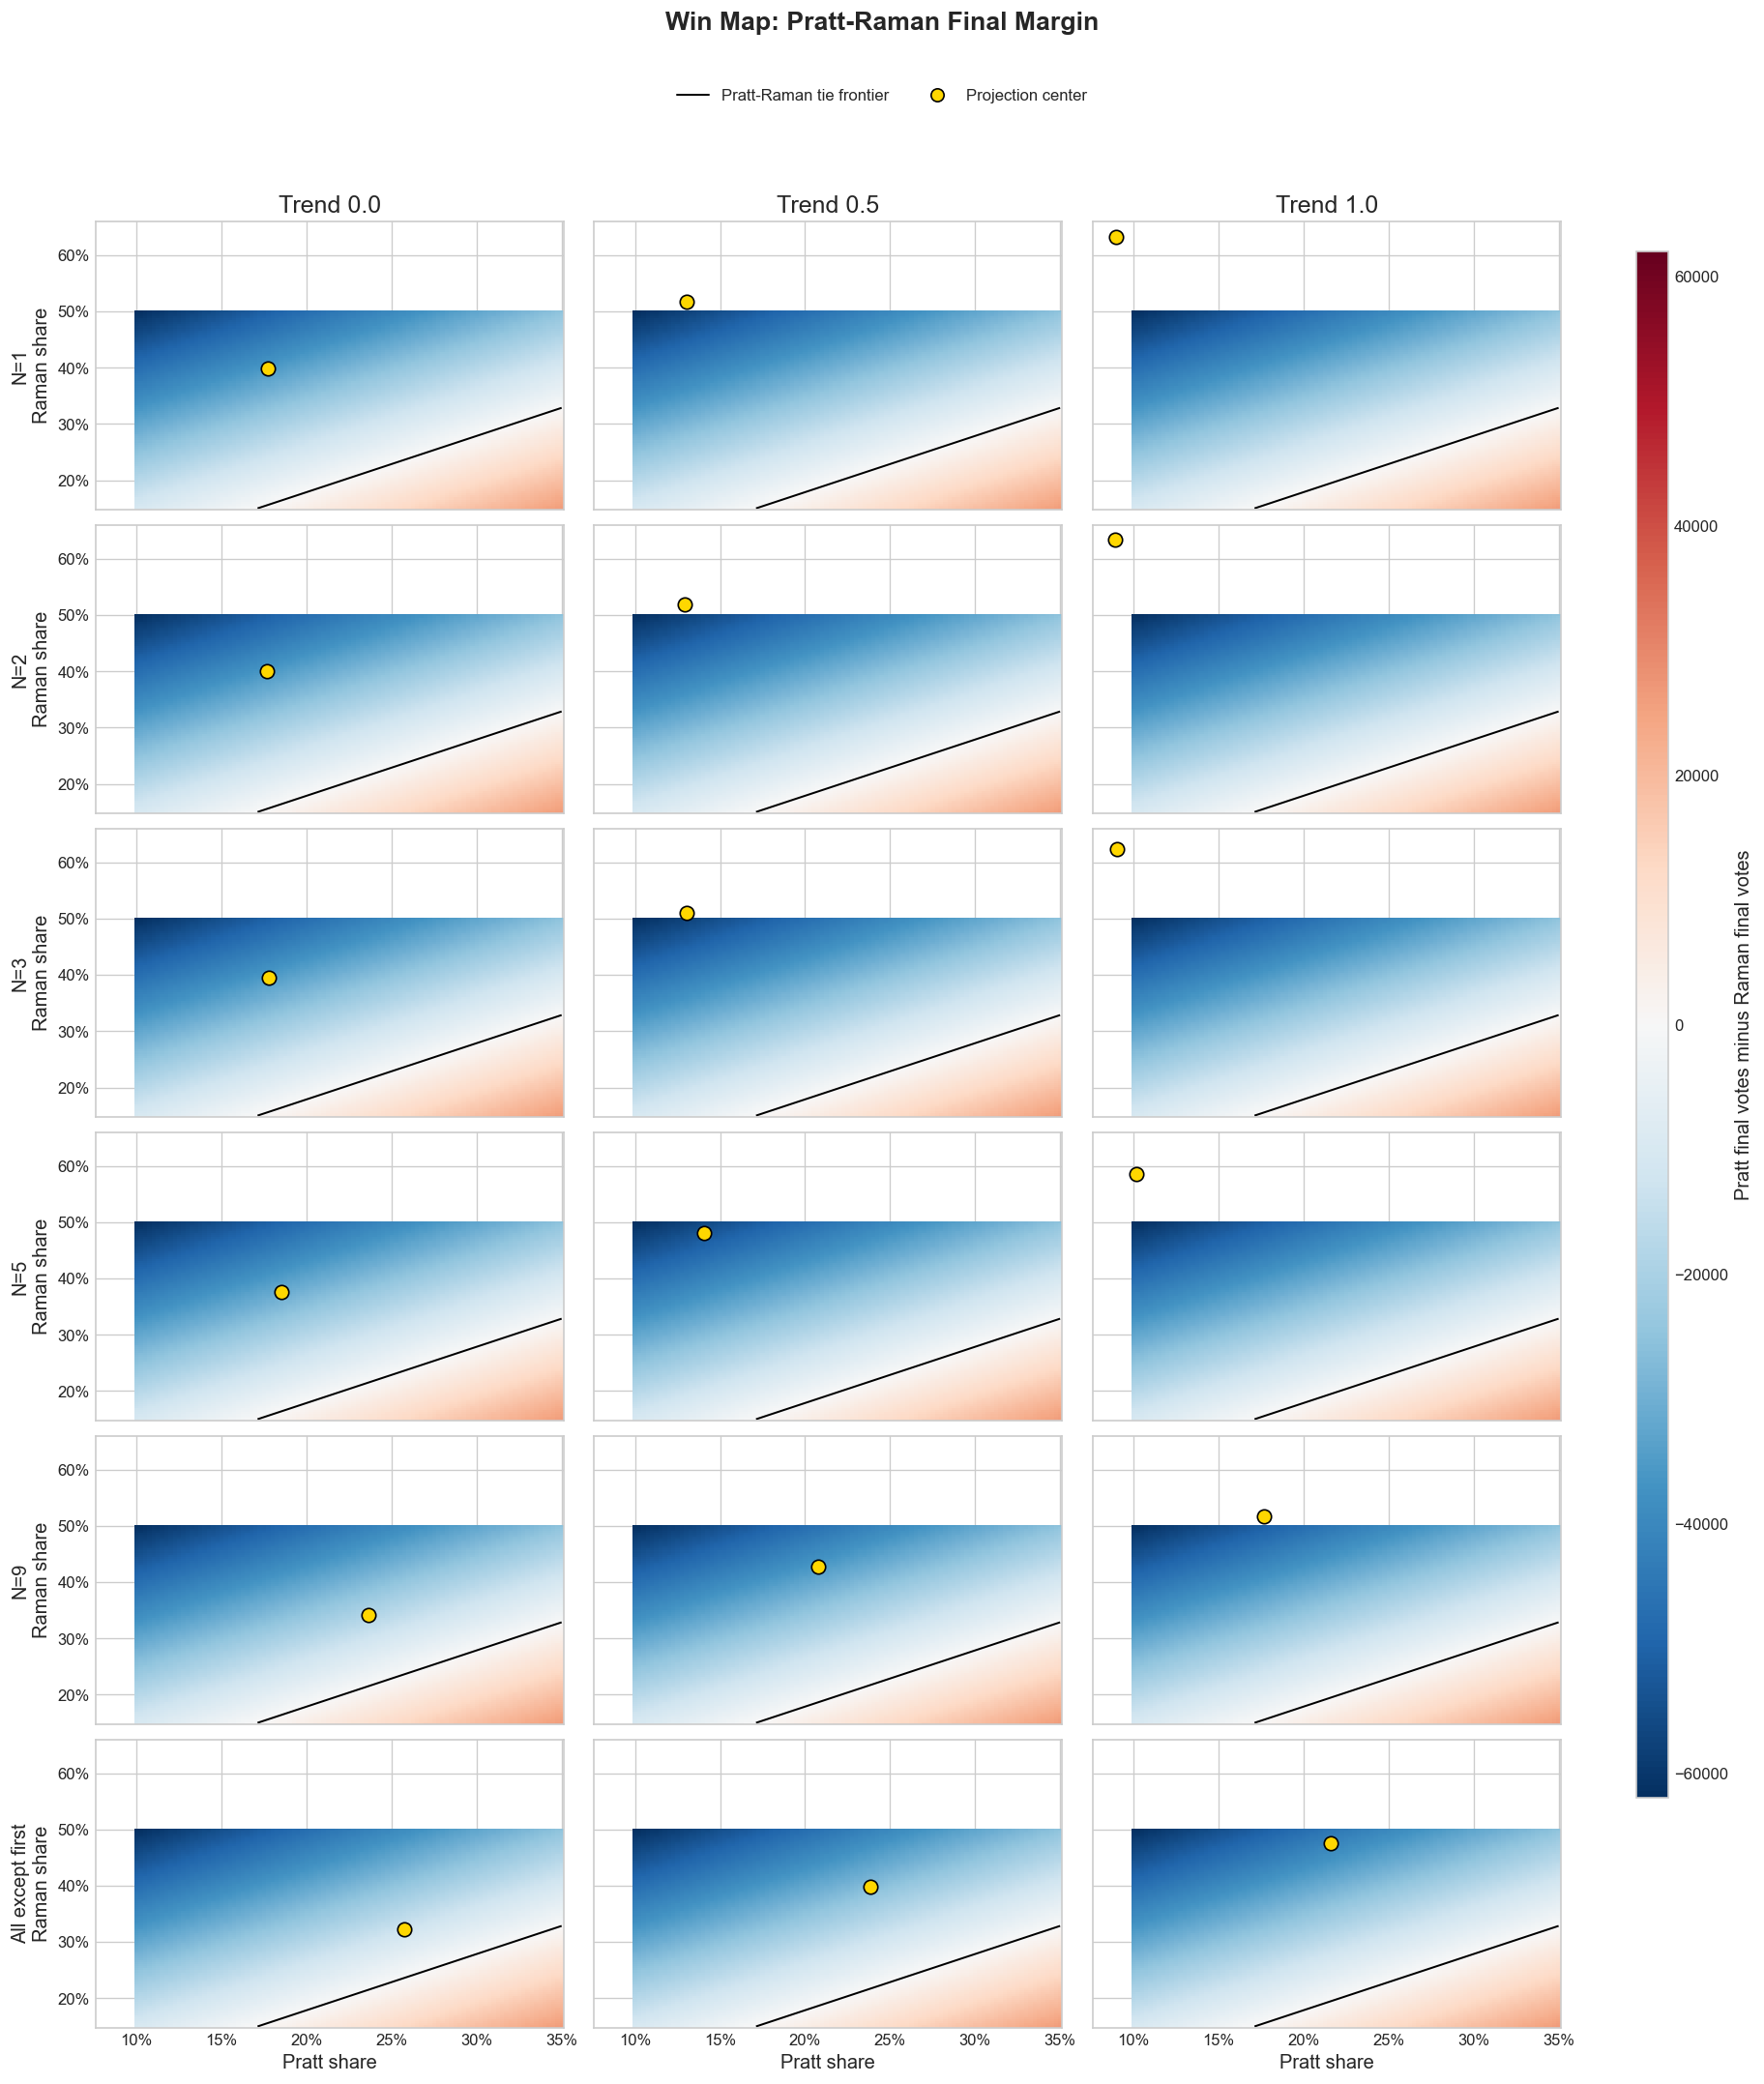

In [7]:
pratt_axis = np.linspace(0.10, 0.35, 101)
raman_axis = np.linspace(0.15, 0.50, 101)
win_map_records = {}
global_abs_margin = 0

for result in scenario_results:
    other_fixed = float(result["simulated_mean_remaining_share"]["Other"])
    margin_grid = np.full((len(raman_axis), len(pratt_axis)), np.nan)
    for i, raman_share in enumerate(raman_axis):
        for j, pratt_share in enumerate(pratt_axis):
            bass_share = 1 - pratt_share - raman_share - other_fixed
            if bass_share < 0:
                continue
            shares = np.array([bass_share, pratt_share, raman_share, other_fixed], dtype=float)
            deterministic_final = current_vote_values + shares * remaining_votes
            margin_grid[i, j] = deterministic_final[candidates.index("Pratt")] - deterministic_final[candidates.index("Raman")]
    win_map_records[result["key"]] = {"margin_grid": margin_grid, "other_fixed": other_fixed}
    if np.isfinite(margin_grid).any():
        global_abs_margin = max(global_abs_margin, float(np.nanmax(np.abs(margin_grid))))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols + 0.9, 2.9 * n_rows + 0.6), sharex=True, sharey=True)
if n_rows == 1:
    axes = np.array([axes])
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)

mesh = None
for row_idx, window in enumerate(drop_windows):
    for col_idx, trend_strength in enumerate(LATE_TREND_STRENGTH_VALUES):
        ax = axes[row_idx, col_idx]
        result = scenario_lookup[(window["label"], trend_strength)]
        record = win_map_records[result["key"]]
        margin_grid = record["margin_grid"]
        mesh = ax.pcolormesh(
            pratt_axis,
            raman_axis,
            margin_grid,
            shading="auto",
            cmap="RdBu_r",
            vmin=-global_abs_margin,
            vmax=global_abs_margin,
        )
        if np.nanmin(margin_grid) <= 0 <= np.nanmax(margin_grid):
            ax.contour(pratt_axis, raman_axis, margin_grid, levels=[0], colors="black", linewidths=1.2)
        mean_share = result["simulated_mean_remaining_share"]
        ax.scatter(
            mean_share["Pratt"],
            mean_share["Raman"],
            s=75,
            color="gold",
            edgecolor="black",
            zorder=3,
        )
        if row_idx == 0:
            ax.set_title(f"Trend {trend_strength:.1f}")
        if col_idx == 0:
            ax.set_ylabel(f"{window['label']}\nRaman share")
        if row_idx == n_rows - 1:
            ax.set_xlabel("Pratt share")
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

tie_handle = plt.Line2D([0], [0], color="black", linewidth=1.2, label="Pratt-Raman tie frontier")
mean_handle = plt.Line2D([0], [0], marker="o", color="gold", markeredgecolor="black", linestyle="None", markersize=8, label="Projection center")
fig.legend(handles=[tie_handle, mean_handle], loc="upper center", bbox_to_anchor=(0.5, 0.965), ncol=2, frameon=False)
fig.suptitle("Win Map: Pratt-Raman Final Margin", y=0.995, fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.90, 0.935], h_pad=1.0, w_pad=1.0)
if mesh is not None:
    cbar_ax = fig.add_axes([0.925, 0.14, 0.018, 0.74])
    cbar = fig.colorbar(mesh, cax=cbar_ax)
    cbar.set_label("Pratt final votes minus Raman final votes")
plt.show()


## Scenario Topology

Rows are vote-drop windows. Columns are trend strengths. Each simplex-style panel holds `Other` fixed at the scenario's simulated mean and shows where Pratt finishes second across constrained Bass/Pratt/Raman share space. The gold dot marks the scenario's simulated mean and is intentionally large for readability.

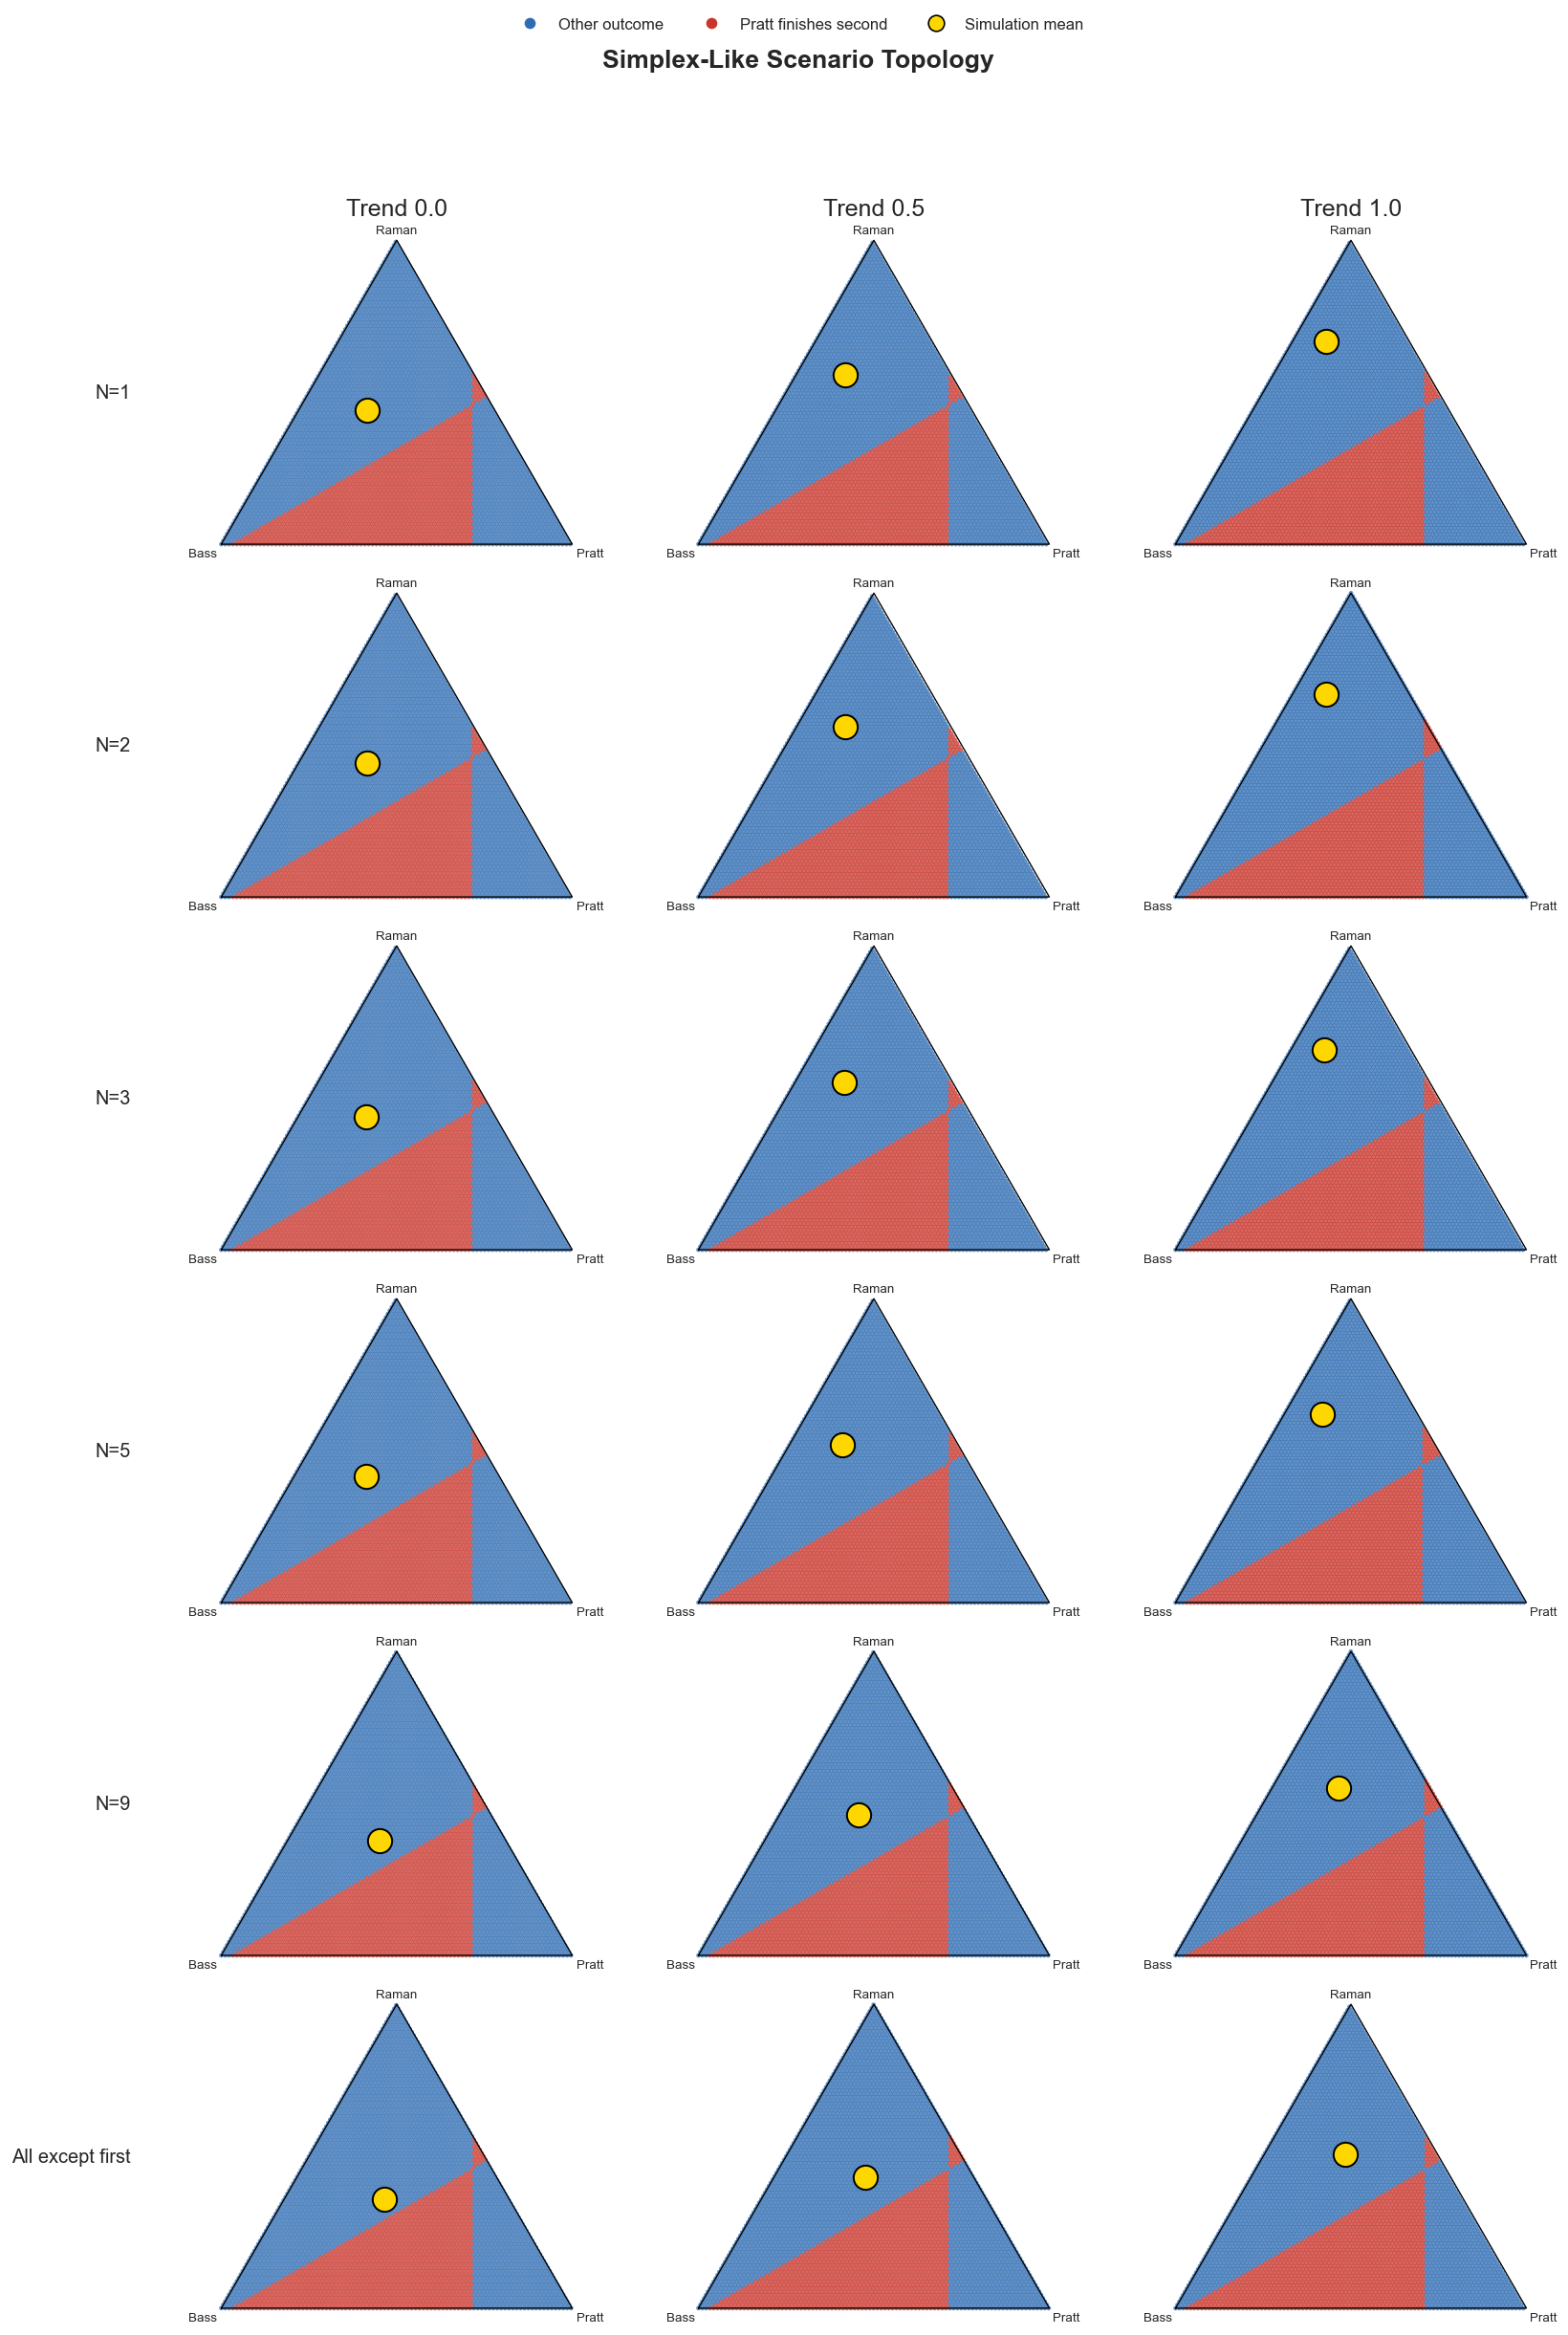

In [8]:
share_step = 0.01
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.8 * n_cols, 3.25 * n_rows + 0.6))
if n_rows == 1:
    axes = np.array([axes])
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)

for row_idx, window in enumerate(drop_windows):
    for col_idx, trend_strength in enumerate(LATE_TREND_STRENGTH_VALUES):
        ax = axes[row_idx, col_idx]
        result = scenario_lookup[(window["label"], trend_strength)]
        other_fixed = float(result["simulated_mean_remaining_share"]["Other"])
        available_major_share = 1 - other_fixed
        simplex_points = []

        for pratt_share in np.arange(0, available_major_share + share_step / 2, share_step):
            for raman_share in np.arange(0, available_major_share - pratt_share + share_step / 2, share_step):
                bass_share = available_major_share - pratt_share - raman_share
                if bass_share < -1e-10:
                    continue
                shares = np.array([bass_share, pratt_share, raman_share, other_fixed], dtype=float)
                deterministic_final = current_vote_values + shares * remaining_votes
                deterministic_ranks = pd.Series(deterministic_final, index=candidates).rank(ascending=False, method="min")
                simplex_points.append({
                    "Bass Share": bass_share,
                    "Pratt Share": pratt_share,
                    "Raman Share": raman_share,
                    "Pratt Finishes Second": deterministic_ranks["Pratt"] == 2,
                })

        simplex_df = pd.DataFrame(simplex_points)
        x = simplex_df["Pratt Share"] + 0.5 * simplex_df["Raman Share"]
        y = (np.sqrt(3) / 2) * simplex_df["Raman Share"]
        ax.scatter(
            x,
            y,
            c=simplex_df["Pratt Finishes Second"].astype(int),
            cmap=ListedColormap(["#2F6DB3", "#C9362C"]),
            s=8,
            alpha=0.75,
            linewidths=0,
        )

        mean_share = result["simulated_mean_remaining_share"]
        mean_x = mean_share["Pratt"] + 0.5 * mean_share["Raman"]
        mean_y = (np.sqrt(3) / 2) * mean_share["Raman"]
        ax.scatter(mean_x, mean_y, s=230, color="gold", edgecolor="black", linewidth=1.2, zorder=4)

        triangle = np.array([
            [0, 0],
            [available_major_share, 0],
            [0.5 * available_major_share, (np.sqrt(3) / 2) * available_major_share],
            [0, 0],
        ])
        ax.plot(triangle[:, 0], triangle[:, 1], color="black", linewidth=0.8)
        ax.text(-0.01, -0.01, "Bass", ha="right", va="top", fontsize=8)
        ax.text(available_major_share + 0.01, -0.01, "Pratt", ha="left", va="top", fontsize=8)
        ax.text(0.5 * available_major_share, (np.sqrt(3) / 2) * available_major_share + 0.01, "Raman", ha="center", va="bottom", fontsize=8)

        if row_idx == 0:
            ax.set_title(f"Trend {trend_strength:.1f}")
        if col_idx == 0:
            ax.set_ylabel(window["label"], rotation=0, ha="right", va="center", labelpad=46)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect("equal")
        ax.spines[["left", "right", "top", "bottom"]].set_visible(False)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#2F6DB3", markersize=8, label="Other outcome"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="#C9362C", markersize=8, label="Pratt finishes second"),
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="gold", markeredgecolor="black", markersize=10, label="Simulation mean"),
]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.015), ncol=3, frameon=False)
fig.suptitle("Simplex-Like Scenario Topology", y=0.995, fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.955], h_pad=0.8, w_pad=0.8)
plt.show()


## Scenario Tables

The first table summarizes the headline outcome for every N/trend scenario. The second table stacks candidate-level projection details for every scenario.

In [9]:
summary_format = {
    "Trend Strength": "{:.1f}",
    "Selected Ballots": "{:,.0f}",
    "Projection Concentration": "{:,.0f}",
    "P(Pratt Finishes Second)": "{:.1%}",
    "P(Raman Finishes Second)": "{:.1%}",
    "P(Bass Finishes First)": "{:.1%}",
    "P(Pratt Beats Raman)": "{:.1%}",
    "Median Pratt-Raman Margin": "{:,.0f}",
    "5th Percentile Margin": "{:,.0f}",
    "95th Percentile Margin": "{:,.0f}",
}

candidate_format = {
    "Trend Strength": "{:.1f}",
    "Current Votes": "{:,.0f}",
    "Current Share": "{:.1%}",
    "First Drop Share": "{:.1%}",
    "Window Share": "{:.1%}",
    "Trend Multiplier": "{:.2f}",
    "Projection Center Share": "{:.1%}",
    "Simulated Mean Remaining Share": "{:.1%}",
    "Simulated Median Final Votes": "{:,.0f}",
    "Simulated Median Final Share": "{:.1%}",
}

display(scenario_summary_table.style.format(summary_format))
display(scenario_candidate_table.style.format(candidate_format))


,N Window,Trend Strength,Selected Drop Count,Selected Ballots,Projection Concentration,P(Pratt Finishes Second),P(Raman Finishes Second),P(Bass Finishes First),P(Pratt Beats Raman),Median Pratt-Raman Margin,5th Percentile Margin,95th Percentile Margin
0,N=1,0.0,1,"47,819",50,1.0%,98.5%,99.5%,1.0%,"-36,076","-59,892","-10,694"
1,N=1,0.5,1,"47,819",50,0.0%,86.6%,86.7%,0.0%,"-60,580","-83,271","-35,381"
2,N=1,1.0,1,"47,819",50,0.0%,36.4%,36.4%,0.0%,"-83,721","-103,956","-59,767"
3,N=2,0.0,2,"106,377","2,000",0.0%,100.0%,100.0%,0.0%,"-36,014","-39,930","-32,064"
4,N=2,0.5,2,"106,377","2,000",0.0%,100.0%,100.0%,0.0%,"-60,534","-64,308","-56,692"
5,N=2,1.0,2,"106,377","2,000",0.0%,2.2%,2.2%,0.0%,"-83,497","-86,992","-79,917"
6,N=3,0.0,3,"166,307","2,000",0.0%,100.0%,100.0%,0.0%,"-35,130","-39,031","-31,166"
7,N=3,0.5,3,"166,307","2,000",0.0%,100.0%,100.0%,0.0%,"-59,117","-62,932","-55,293"
8,N=3,1.0,3,"166,307","2,000",0.0%,15.7%,15.7%,0.0%,"-81,685","-85,193","-78,111"
9,N=5,0.0,5,"226,864",632,0.0%,100.0%,100.0%,0.0%,"-31,247","-38,226","-24,235"


,N Window,Trend Strength,Candidate,Current Votes,Current Share,First Drop Share,Window Share,Trend Multiplier,Projection Center Share,Simulated Mean Remaining Share,Simulated Median Final Votes,Simulated Median Final Share
0,N=1,0.0,Bass,"250,871",34.7%,38.1%,32.8%,1.00,32.8%,32.8%,"298,800",34.3%
1,N=1,0.0,Pratt,"193,085",26.7%,27.9%,17.8%,1.00,17.8%,17.7%,"218,540",25.1%
2,N=1,0.0,Raman,"196,198",27.1%,20.1%,39.9%,1.00,39.9%,39.9%,"254,767",29.3%
3,N=1,0.0,Other,"83,318",11.5%,13.9%,9.5%,1.00,9.5%,9.5%,"96,513",11.1%
4,N=1,0.5,Bass,"250,871",34.7%,38.1%,32.8%,0.93,28.0%,28.0%,"291,573",33.5%
5,N=1,0.5,Pratt,"193,085",26.7%,27.9%,17.8%,0.80,13.0%,13.0%,"211,491",24.3%
6,N=1,0.5,Raman,"196,198",27.1%,20.1%,39.9%,1.41,51.8%,51.8%,"272,408",31.3%
7,N=1,0.5,Other,"83,318",11.5%,13.9%,9.5%,0.83,7.2%,7.2%,"93,082",10.7%
8,N=1,1.0,Bass,"250,871",34.7%,38.1%,32.8%,0.86,22.5%,22.5%,"283,457",32.6%
9,N=1,1.0,Pratt,"193,085",26.7%,27.9%,17.8%,0.64,9.0%,9.0%,"205,474",23.6%
